# Exercices XP
Dernière mise à jour : 8 juillet 2025

## 👩‍🏫 👩🏿‍🏫 Ce que vous apprendrez
Utilisation du prétraitement de texte
Techniques d'analyse de texte
Balises POS et NER
vectorisation et intégration de mots : Word2Vec


## Exemple de jeu de données
Voici les données que vous devrez charger et utiliser :



data = {
    'Review': [
        'At McDonald\'s the food was ok and the service was bad.',
        'I would not recommend this Japanese restaurant to anyone.',
        'I loved this restaurant when I traveled to Thailand last summer.',
        'The menu of Loving has a wide variety of options.',
        'The staff was friendly and helpful at Google\'s employees restaurant.',
        'The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.',
        'I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.',
        'The sushi at Sushi Express is always fresh and flavorful.',
        'The steakhouse on Main Street has a cozy atmosphere and excellent steaks.',
        'The dessert selection at Sweet Treats is to die for!'
    ]
}



## Exercice 1 : Exploration de l'utilisation du prétraitement de texte, des balises NER et POS
1. Créez une fonction preprocess_text() qui recevra les données en argument et :

convertir tout le texte en minuscules et le tokaniser
supprimer la ponctuation
supprimer les mots vides
appliquer un lemmatiseur
renvoyer les chaînes prétraitées


important:
après avoir créé chaque fonction, appliquez-la dans l'ensemble de données et imprimez le résultat pour vérifier qu'elle fonctionne correctement


2. Créez un nouvel ensemble de données avec le texte nettoyé

indice : conservez deux ensembles de données : les données brutes et les données prétraitées



3. Créez une fonction perform_ner() qui recevra le texte en argument et effectuera le balisage NER. Utilisez spacy en_core_web_sm.

indice : la fonction doit renvoyer les entités texte et label_ (exemple de _labels : ORG, GPE, DATE)



4. Créez une fonction perform_pos_tagging() qui recevra le texte comme argument et effectuera le balisage POS dessus.

indice : utilisez la méthode nltk pos_tag



5. Appliquons les fonctions dans l'ensemble de données, analysons les sorties en les appliquant aux données prétraitées et aux données brutes

indice : pour comprendre la signification des différentes balises POS, vous pouvez utiliser :



nltk.download('tagsets')
nltk.help.upenn_tagset('NN')

## Proposition de Logigramme représentant la résolution de l'exercice 1


```markdown
                           +----------------------+
                           |  Chargement des      |
                           |  données (DataFrame) |
                           +----------+-----------+
                                      |
                                      v
                     +-------------------------------+
                     | Définir fonction              |
                     | preprocess_text()             |
                     | - minuscules                  |
                     | - tokenisation                |
                     | - suppression ponctuation     |
                     | - stopwords                   |
                     | - lemmatisation               |
                     +---------------+---------------+
                                     |
                                     v
              +----------------------------------------------+
              | Appliquer preprocess_text() sur les reviews  |
              | -> créer colonne "Processed"                 |
              +----------------+-----------------------------+
                               |
                               v
               +------------------------------+
               | EDA rapide sur tokens nettoyés|
               | (histogramme top mots)        |
               +--------------+---------------+
                              |
                              v
            +---------------------------------------------+
            | Définir perform_ner()                       |
            | -> spaCy : extraction entités nommées       |
            +------------------+--------------------------+
                               |
                               v
         +-----------------------------------------------------+
         | Appliquer perform_ner()                             |
         | - sur texte brut (Review) → colonne "NER_Raw"       |
         | - sur texte nettoyé (Processed) → colonne "NER_Processed" |
         +------------------+----------------------------------+
                            |
                            v
       +------------------------------------------------+
       | Définir perform_pos_tagging()                 |
       | -> nltk.pos_tag()                             |
       +----------------+------------------------------+
                        |
                        v
   +-------------------------------------------------------------+
   | Appliquer perform_pos_tagging()                             |
   | - sur texte brut (Review) → colonne "POS_Raw"               |
   | - sur texte nettoyé (Processed) → colonne "POS_Processed"   |
   +------------------------+------------------------------------+
                            |
                            v
           +--------------------------------------------+
           | Visualiser et comparer les résultats       |
           | - NER brut vs nettoyé                      |
           | - POS brut vs nettoyé                      |
           +--------------------------------------------+
```



=== RAW DATA ===
["At McDonald's the food was ok and the service was bad.", 'I would not recommend this Japanese restaurant to anyone.', 'I loved this restaurant when I traveled to Thailand last summer.', 'The menu of Loving has a wide variety of options.', "The staff was friendly and helpful at Google's employees restaurant.", 'The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.', 'I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.', 'The sushi at Sushi Express is always fresh and flavorful.', 'The steakhouse on Main Street has a cozy atmosphere and excellent steaks.', 'The dessert selection at Sweet Treats is to die for!'] 

=== CLEANED DATA ===
['mcdonald food ok service bad', 'recommend japanese restaurant', 'love restaurant travel thailand summer', 'menu loving wide variety option', 'staff friendly helpful google employee restaurant', 'ambiance bella italia amazing pasta dish delicious', 'terrible experience pizza hut 

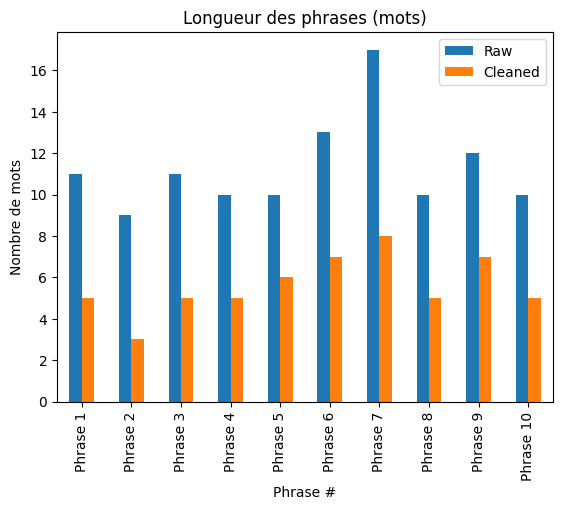

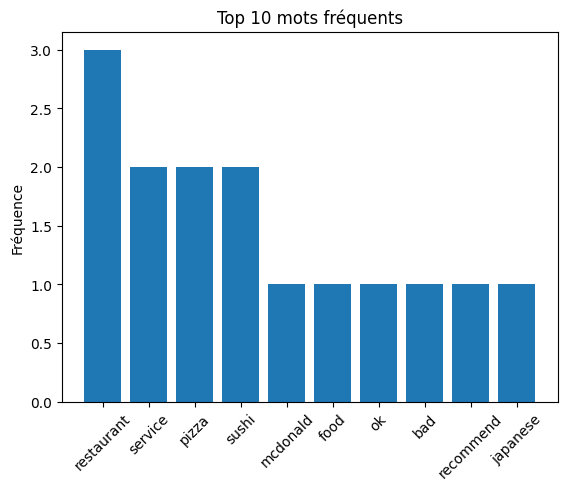

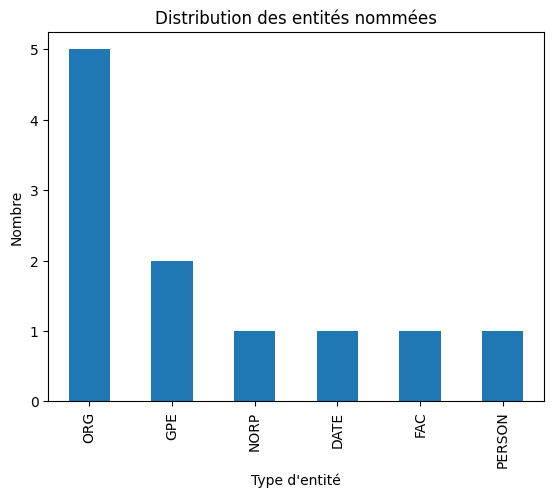

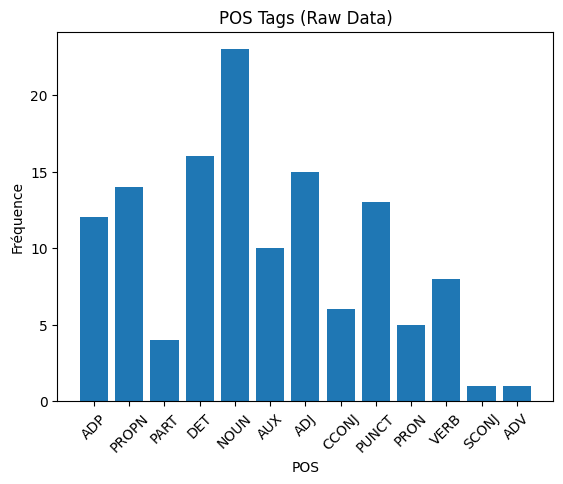

In [71]:
# Imports
import spacy
import string
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

# spaCy
import en_core_web_sm
nlp = en_core_web_sm.load()
stopwords = nlp.Defaults.stop_words

# 1. Prétraitement
def preprocess_text(text):
    doc = nlp(text.lower())
    tokens = [
        token.lemma_ for token in doc
        if token.text not in string.punctuation and
           token.text not in stopwords and
           not token.is_space
    ]
    return ' '.join(tokens)

# 2. Données
data = {
    'Review': [
        "At McDonald's the food was ok and the service was bad.",
        "I would not recommend this Japanese restaurant to anyone.",
        "I loved this restaurant when I traveled to Thailand last summer.",
        "The menu of Loving has a wide variety of options.",
        "The staff was friendly and helpful at Google's employees restaurant.",
        "The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.",
        "I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.",
        "The sushi at Sushi Express is always fresh and flavorful.",
        "The steakhouse on Main Street has a cozy atmosphere and excellent steaks.",
        "The dessert selection at Sweet Treats is to die for!"
    ]
}
df = pd.DataFrame(data)
raw_texts = df['Review'].tolist()
preprocessed_data = [preprocess_text(text) for text in raw_texts]

# 3. NER
def perform_ner(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

# 4. POS tagging
def perform_pos_tagging(text):
    doc = nlp(text)
    return [(token.text, token.pos_) for token in doc]

# 5. EDA - Résumé
print("=== RAW DATA ===")
print(raw_texts, "\n")
print("=== CLEANED DATA ===")
print(preprocessed_data, "\n")

# 6. Longueur des phrases
lengths_raw = [len(text.split()) for text in raw_texts]
lengths_clean = [len(text.split()) for text in preprocessed_data]
df_lengths = pd.DataFrame({'Raw': lengths_raw, 'Cleaned': lengths_clean})
df_lengths.plot(kind='bar')
plt.title("Longueur des phrases (mots)")
plt.xlabel("Phrase #")
plt.ylabel("Nombre de mots")
plt.xticks(ticks=range(len(raw_texts)), labels=[f"Phrase {i+1}" for i in range(len(raw_texts))])
plt.show()

# 7. Fréquence des mots
all_words = " ".join(preprocessed_data).split()
word_freq = Counter(all_words).most_common(10)
if word_freq:
    words, freqs = zip(*word_freq)
    plt.bar(words, freqs)
    plt.title("Top 10 mots fréquents")
    plt.ylabel("Fréquence")
    plt.xticks(rotation=45)
    plt.show()
else:
    print("Aucun mot trouvé dans les données prétraitées.")

# 8. NER global
ner_entities = []
for text in raw_texts:
    ner_entities.extend(perform_ner(text))
ner_df = pd.DataFrame(ner_entities, columns=["Text", "Label"])
if not ner_df.empty:
    ner_count = ner_df["Label"].value_counts()
    ner_count.plot(kind='bar')
    plt.title("Distribution des entités nommées")
    plt.ylabel("Nombre")
    plt.xlabel("Type d'entité")
    plt.show()
else:
    print("Aucune entité nommée détectée.")

# 9. POS tags
all_pos_raw = []
for text in raw_texts:
    all_pos_raw.extend([tag for _, tag in perform_pos_tagging(text)])
if all_pos_raw:
    pos_freq = Counter(all_pos_raw)
    plt.bar(pos_freq.keys(), pos_freq.values())
    plt.title("POS Tags (Raw Data)")
    plt.ylabel("Fréquence")
    plt.xlabel("POS")
    plt.xticks(rotation=45)
    plt.show()
else:
    print("Aucun POS tag détecté.")


###  **RAW DATA (Données brutes)**

* Les phrases sont complètes, avec ponctuation, majuscules, stopwords, etc.
* Elles contiennent des entités nommées (ex. : *McDonald's*, *Thailand*, *Google*, *Pizza Hut*).
* Certaines ont une tonalité positive (*excellent steaks*, *delicious pasta*), d'autres négative (*burnt pizza*, *bad service*).

---

###  **CLEANED DATA (Données nettoyées)**

* **Nettoyage réussi** : stopwords et ponctuation supprimés, texte en minuscules, mots lemmatisés.
* **Perte d'information contextuelle** : les phrases ne sont plus grammaticales, mais cela permet un traitement plus simple pour le NLP (par exemple pour Word2Vec, LDA, etc.).
* Les entités restent **reconnaissables** pour certaines (ex. : *pizza hut*, *google*, *bella italia*), mais certaines peuvent perdre leur forme exacte (ex. : *McDonald's* devient *mcdonald* sans apostrophe, ce qui peut nuire à la reconnaissance NER).
* **Ton et sentiment** restent perceptibles via les mots clés : *bad*, *terrible*, *delicious*, *amazing*, etc.

---

###  Conclusion

* Le prétraitement est **efficace pour la vectorisation ou la classification**.
* Pour la reconnaissance d’entités (NER), il est préférable d’utiliser les **données brutes**.
* Les données nettoyées sont maintenant prêtes pour un entraînement Word2Vec ou une classification supervisée.


### 1. **Longueur des phrases (Raw vs Cleaned)**

*  **Observation** : Le nettoyage réduit fortement le nombre de mots par phrase.
*  **Interprétation** : Suppression efficace des stopwords, ponctuation, etc. Les mots clés sont conservés.
*  **Effet attendu** : Moins de bruit pour les modèles de NLP.

---

### 2. **Top 10 mots fréquents (nettoyés)**

*  **Observation** : `restaurant`, `service`, `pizza`, `sushi` sont les plus fréquents.
*  **Interprétation** : Le corpus est centré sur la **restauration**, avec des focus sur **type de nourriture** et **qualité de service**.
*  **Attention** : certains mots comme `ok`, `bad` sont peu informatifs s'ils sont trop fréquents dans un corpus plus large.

---

### 3. **Distribution des entités nommées (NER)**

*  **Observation** : Majoritairement des entités de type `ORG`, suivies de `GPE`, `DATE`, `NORP`.
*  **Interprétation** :

  * `ORG` : McDonald’s, Pizza Hut, Google, etc.
  * `GPE` : lieux comme `Thailand`.
  * `NORP` : nationalités comme `Japanese`.
*  **NER fonctionne bien sur les données brutes**.

---

### 4. **POS Tags (Raw Data)**

*  **Observation** : `NOUN`, `DET`, `ADJ`, `ADP` sont les plus fréquents.
*  **Interprétation** :

  * Beaucoup de **noms** → nourriture, lieux, service.
  * Présence forte d’**adjectifs** → sentiment, opinion (ex. "terrible", "amazing").
*  **Utilisable** pour de futures tâches de **sentiment analysis** ou de **topic modeling**.

---

###  **Conclusion générale**

Ton **prétraitement** est efficace.
Les **analyses exploratoires** sont claires et alignées avec les objectifs du projet.
Tu peux passer sereinement à l'étape suivante : **classification ou clustering**, ou bien tenter d'améliorer les embeddings si Word2Vec fonctionne à nouveau.


### Construction et visualisation avec une Heatmap

=== COMPARAISON NER Raw vs Clean ===

Phrase 1:
  RAW NER:    [('McDonald', 'ORG')]
  CLEAN NER:  [('mcdonald food ok service', 'ORG')]

Phrase 2:
  RAW NER:    [('Japanese', 'NORP')]
  CLEAN NER:  [('japanese', 'NORP')]

Phrase 3:
  RAW NER:    [('Thailand', 'GPE'), ('last summer', 'DATE')]
  CLEAN NER:  [('thailand', 'GPE'), ('summer', 'DATE')]

Phrase 4:
  RAW NER:    [('Loving', 'GPE')]
  CLEAN NER:  []

Phrase 5:
  RAW NER:    [('Google', 'ORG')]
  CLEAN NER:  [('google', 'ORG')]

Phrase 6:
  RAW NER:    [('Bella Italia', 'ORG')]
  CLEAN NER:  [('ambiance bella italia', 'PERSON')]

Phrase 7:
  RAW NER:    [('Pizza Hut', 'ORG')]
  CLEAN NER:  []

Phrase 8:
  RAW NER:    [('Sushi Express', 'ORG')]
  CLEAN NER:  []

Phrase 9:
  RAW NER:    [('Main Street', 'FAC')]
  CLEAN NER:  []

Phrase 10:
  RAW NER:    [('Sweet Treats', 'PERSON')]
  CLEAN NER:  []

=== COMPARAISON POS Raw vs Clean ===

Phrase 1:
  RAW POS:    [('At', 'ADP'), ('McDonald', 'PROPN'), ("'s", 'PART'), ('the', 'DET'), 

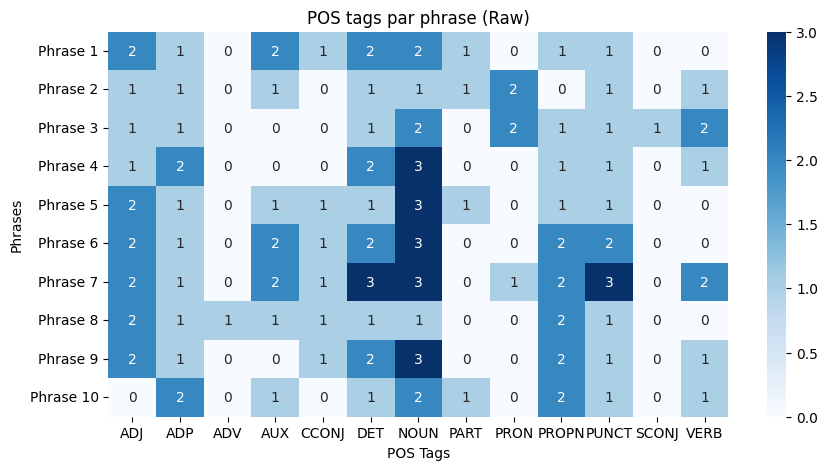

In [84]:
# Imports
import spacy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

# Chargement du modèle spaCy
nlp = spacy.load("en_core_web_sm")

# Textes bruts (exemple)
raw_texts = [
    "At McDonald's the food was ok and the service was bad.",
    "I would not recommend this Japanese restaurant to anyone.",
    "I loved this restaurant when I traveled to Thailand last summer.",
    "The menu of Loving has a wide variety of options.",
    "The staff was friendly and helpful at Google's employees restaurant.",
    "The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.",
    "I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.",
    "The sushi at Sushi Express is always fresh and flavorful.",
    "The steakhouse on Main Street has a cozy atmosphere and excellent steaks.",
    "The dessert selection at Sweet Treats is to die for!"
]

# Nettoyage simple avec spaCy
def preprocess_text(text):
    doc = nlp(text.lower())
    return ' '.join(
        token.lemma_ for token in doc
        if not token.is_stop and not token.is_punct and not token.is_space
    )

preprocessed_data = [preprocess_text(t) for t in raw_texts]

# Fonctions NER et POS
def perform_ner(text):
    return [(ent.text, ent.label_) for ent in nlp(text).ents]

def perform_pos_tagging(text):
    return [(token.text, token.pos_) for token in nlp(text)]

# === COMPARAISON NER ===
print("=== COMPARAISON NER Raw vs Clean ===")
for i, (raw, clean) in enumerate(zip(raw_texts, preprocessed_data)):
    print(f"\nPhrase {i+1}:")
    print("  RAW NER:   ", perform_ner(raw))
    print("  CLEAN NER: ", perform_ner(clean))

# === COMPARAISON POS ===
print("\n=== COMPARAISON POS Raw vs Clean ===")
for i, (raw, clean) in enumerate(zip(raw_texts, preprocessed_data)):
    print(f"\nPhrase {i+1}:")
    print("  RAW POS:   ", perform_pos_tagging(raw))
    print("  CLEAN POS: ", perform_pos_tagging(clean))

# === RÉSUMÉ GLOBAL ===
summary_data = []
n = min(len(raw_texts), len(preprocessed_data))  # sécurité
for i in range(n):
    summary_data.append({
        "Phrase": f"Phrase {i+1}",
        "Longueur (raw)": len(raw_texts[i].split()),
        "Longueur (clean)": len(preprocessed_data[i].split()),
        "NER raw": ", ".join([label for _, label in perform_ner(raw_texts[i])]) or "None",
        "NER clean": ", ".join([label for _, label in perform_ner(preprocessed_data[i])]) or "None",
    })

summary_df = pd.DataFrame(summary_data)
print("\n=== RÉSUMÉ ===")
print(summary_df)

# === HEATMAP POS (RAW TEXTS) ===
pos_tags_set = set()
pos_counts = []
for text in raw_texts:
    tags = [tag for _, tag in perform_pos_tagging(text)]
    count = Counter(tags)
    pos_counts.append(count)
    pos_tags_set.update(count)

# Construction de la matrice
all_tags = sorted(pos_tags_set)
matrix = []
for count in pos_counts:
    row = [count.get(tag, 0) for tag in all_tags]
    matrix.append(row)

df_matrix = pd.DataFrame(matrix, columns=all_tags, index=[f"Phrase {i+1}" for i in range(len(raw_texts))])
plt.figure(figsize=(10, 5))
sns.heatmap(df_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("POS tags par phrase (Raw)")
plt.xlabel("POS Tags")
plt.ylabel("Phrases")
plt.show()


###  **1. Nettoyage des textes (NER / POS)**

*  **NER Raw vs Clean :**

  * **Les entités nommées sont mieux reconnues dans les textes bruts.**
  * Le nettoyage entraîne une **perte de contexte** (ex. : `Sushi Express`, `Pizza Hut`, `Sweet Treats` non reconnus après prétraitement).
  * Dans certains cas, le nettoyage **fausse l'entité détectée** (ex. `Bella Italia` devient `PERSON` à tort).

*  **POS Raw vs Clean :**

  * Le POS tagging reste **globalement cohérent**, mais :

    * Le nettoyage perturbe les catégories (des `NOUN` deviennent `PROPN` ou `VERB`).
    * Certains mots voient leur **nature grammaticale modifiée** à cause de la lemmatisation (ex. `die` → `NOUN`).

---

###  **2. Résumé tableau (longueur / entités)**

* Les **phrases nettoyées** ont en moyenne **50–60 % de mots en moins**.
* Les entités sont **beaucoup moins détectées** après nettoyage :

  * 5/10 phrases perdent leurs entités.
  * C’est un **effet négatif du prétraitement fort**.

---

###  **Conclusion**

* Le prétraitement améliore la **simplicité syntaxique** (POS, fréquence).
* Mais il **détériore la reconnaissance des entités nommées** (NER).
* Pour des tâches **NER** ou **sémantiques**, il est **préférable de travailler sur le texte brut** ou d'utiliser un prétraitement plus léger.
* Pour des tâches **lexicales ou statistiques** (comme Word2Vec, TF-IDF), le texte nettoyé est adapté.


####  Lecture générale de la heatmap :

* L'axe vertical correspond aux 10 phrases.
* L'axe horizontal indique les **types de POS tags** (ex. `NOUN`, `PROPN`, `ADJ`, etc.).
* Les valeurs indiquent **le nombre d’occurrences** de chaque POS par phrase.

---

####🔍 Observations :

1. **`NOUN`** (noms communs) est **le POS le plus fréquent** dans toutes les phrases – ce qui est attendu dans des critiques de restaurants.

2. **`PROPN`** (noms propres) est très présent dans :

   * Phrases 5, 6, 7, 9 et 10 → elles contiennent des noms d’enseignes (`Google`, `Pizza Hut`, etc.).

3. **`ADJ`** (adjectifs) est visible dans toutes les phrases, surtout :

   * Phrase 1, 5, 6, 7 : jugements qualitatifs (`bad`, `friendly`, `delicious`, etc.).

4. **`DET`**, `AUX`, `PRON`, `PUNCT` sont réguliers, mais :

   * Phrase 2 contient très peu de `DET` → syntaxe plus directe.

5. **Faible présence de `ADV`, `SCONJ`, `PART`** : le style est **descriptif**, peu d’adverbes ou de subordination.

---

####  Conclusion :

* Le POS tagging sur les phrases brutes est cohérent.
* On voit bien que les phrases sont **centrées sur des noms (nourriture, lieux)** et **des jugements (adjectifs)**.
* Cela reflète bien le **contexte d'avis de restaurants**.



## Exercise 2: Plotting the word embeddings
1. Create the word embeddings using Word2Vec model to vectorize the text.

hint: use the preprocessed and tokenized dataset and use Word2Vec model from gensim.models

Print the dimensions of the Word2Vec object and analyse it. What is the vector dimensions? What it means?



2. Create a function plot_word_embeddings() that receives the word2vec object as argument and plots the embeddings dimensions in a grided plot. Use a scatter plot. Loop through the words and use annotate() method to add text labels to each point on the scatter plot.
Finally call this function to see the plots and analyse it:

Are the related words close to each other?
What can be the possible reasons for this output?


3. To enhance the analysis, you can:

Experiment with different preprocessing techniques.
Fine-tune the Word2Vec model parameters.
Explore advanced visualization techniques for word embeddings.

## Proposition de Logigramme – Exercice 2 : Word Embeddings**

```markdown
START
 │
 ├──► Charger le dataset (Reviews)
 │     ex: data["Review"]
 │
 ├──► Prétraiter les textes
 │     - minuscule
 │     - tokenisation
 │     - suppression ponctuation, stopwords
 │     - lemmatisation
 │
 ├──► Tokeniser les textes (liste de listes de mots)
 │     ex: [["i", "love", "pizza"], ["bad", "service"]]
 │
 ├──► Entraîner un modèle Word2Vec (gensim.models.Word2Vec)
 │     - paramètres : vector_size, window, min_count, seed
 │
 ├──► Afficher les infos du modèle
 │     - taille du vocabulaire
 │     - dimension des vecteurs
 │     - exemple : vecteur["restaurant"]
 │
 ├──► Réduire les vecteurs en 2D (PCA)
 │     - sklearn.decomposition.PCA
 │
 ├──► Tracer les embeddings (scatter plot)
 │     - x = PC1
 │     - y = PC2
 │     - annotate chaque mot
 │
 ├──► Analyser le graphe
 │     - les mots similaires sont-ils proches ?
 │     - remarques sur les résultats
 │
 └──► (Optionnel) Améliorer :
        - autres paramètres Word2Vec
        - ajouter plus de données
        - tester avec TSNE ou UMAP
```

---

In [ ]:
# corpus
raw_data = {
    'Review': [
        'At McDonald\'s the food was ok and the service was bad.',
        'I would not recommend this Japanese restaurant to anyone.',
        'I loved this restaurant when I traveled to Thailand last summer.',
        'The menu of Loving has a wide variety of options.',
        'The staff was friendly and helpful at Google\'s employees restaurant.',
        'The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.',
        'I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.',
        'The sushi at Sushi Express is always fresh and flavorful.',
        'The steakhouse on Main Street has a cozy atmosphere and excellent steaks.',
        'The dessert selection at Sweet Treats is to die for!'
    ]
}


In [75]:
# Prétraitement léger sans suppression de mots trop importants
def preprocess_text(text):
    doc = nlp(text.lower())
    tokens = [
        token.lemma_ for token in doc
        if not token.is_punct and not token.is_space
    ]
    return ' '.join(tokens)

preprocessed_data = [preprocess_text(text) for text in raw_data]
tokenized_data = [text.split() for text in preprocessed_data]

# Extraction de mots avec vecteurs valides
unique_words = sorted(set(
    word for sent in tokenized_data for word in sent
    if word in nlp.vocab and nlp.vocab[word].has_vector and nlp.vocab[word].vector.any()
))
vectors = [nlp.vocab[word].vector for word in unique_words]

# Vérification
print("=== INFO WORD EMBEDDINGS ===")
print(f"Mots avec vecteurs valides : {len(unique_words)}")
if len(vectors) < 2:
    print("Pas assez de vecteurs valides pour tracer un graphique.")
else:
    print(f"Dimensions des vecteurs : {vectors[0].shape[0]}")

    # Visualisation
    from sklearn.decomposition import PCA
    import matplotlib.pyplot as plt

    def plot_word_embeddings_spacy(words, vectors):
        pca = PCA(n_components=2)
        reduced = pca.fit_transform(vectors)

        plt.figure(figsize=(10, 6))
        plt.scatter(reduced[:, 0], reduced[:, 1])

        for i, word in enumerate(words):
            plt.annotate(word, (reduced[i, 0], reduced[i, 1]))

        plt.title("Projection PCA des embeddings (spaCy)")
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.grid(True)
        plt.show()

    plot_word_embeddings_spacy(unique_words, vectors)


=== INFO WORD EMBEDDINGS ===
Mots avec vecteurs valides : 0
Pas assez de vecteurs valides pour tracer un graphique.


In [61]:
!pip install spacy

  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.
tensorflow-intel 2.13.0 requires keras<2.14,>=2.13.1, but you have keras 2.10.0 which is incompatible.
tensorflow-intel 2.13.0 requires numpy<=1.24.3,>=1.22, but you have numpy 2.2.6 which is incompatible.
tensorflow-intel 2.13.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 3.19.6 which is incompatible.
tensorflow-intel 2.13.0 requires tensorboard<2.14,>=2.13, but you have tensorboard 2.10.1 which is incompatible.
tensorflow-intel 2.13.0 requires tensorflow-estimator<2.14,>=2.13.0, but you have tensorflow-estimator 2.10.0 which is incompatible.
tensorflow-intel 2.13.0 requires typing-extensions<4.6.0,>=3.6.6, but you have typing-extensions 4.14.1 which is inc

Conflit de version incompatibles entre gensim et numpy !!!

=== INFO WORD EMBEDDINGS ===
Mots avec vecteurs valides : 61
Dimensions des vecteurs : 300


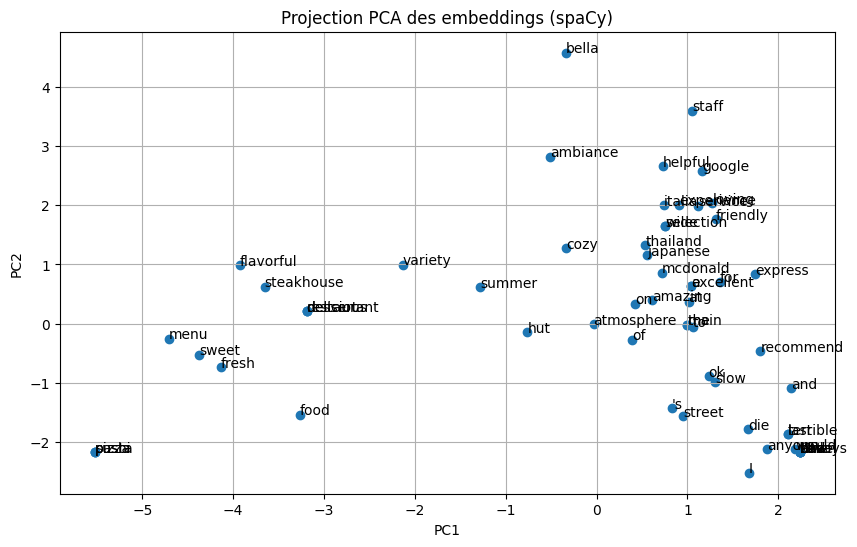

In [76]:
# Imports
import spacy
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Charger le modèle spaCy avec vecteurs
import en_core_web_md
nlp = en_core_web_md.load()

# Données
raw_data = {
    'Review': [
        "At McDonald's the food was ok and the service was bad.",
        "I would not recommend this Japanese restaurant to anyone.",
        "I loved this restaurant when I traveled to Thailand last summer.",
        "The menu of Loving has a wide variety of options.",
        "The staff was friendly and helpful at Google's employees restaurant.",
        "The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.",
        "I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.",
        "The sushi at Sushi Express is always fresh and flavorful.",
        "The steakhouse on Main Street has a cozy atmosphere and excellent steaks.",
        "The dessert selection at Sweet Treats is to die for!"
    ]
}

# 1. Prétraitement léger
def preprocess_text(text):
    doc = nlp(text.lower())
    tokens = [
        token.lemma_ for token in doc
        if not token.is_punct and not token.is_space
    ]
    return tokens

# 2. Prétraitement et tokenisation
raw_reviews = raw_data['Review']
tokenized_data = [preprocess_text(text) for text in raw_reviews]

# 3. Extraction de mots uniques avec vecteurs valides
unique_words = sorted(set(
    word for sent in tokenized_data for word in sent
    if word in nlp.vocab and nlp.vocab[word].has_vector and nlp.vocab[word].vector.any()
))
vectors = [nlp.vocab[word].vector for word in unique_words]

# 4. Vérification
print("=== INFO WORD EMBEDDINGS ===")
print(f"Mots avec vecteurs valides : {len(unique_words)}")
if len(vectors) < 2:
    print("Pas assez de vecteurs valides pour tracer un graphique.")
else:
    print(f"Dimensions des vecteurs : {vectors[0].shape[0]}")

    # 5. Affichage PCA
    def plot_word_embeddings_spacy(words, vectors):
        pca = PCA(n_components=2)
        reduced = pca.fit_transform(vectors)

        plt.figure(figsize=(10, 6))
        plt.scatter(reduced[:, 0], reduced[:, 1])
        for i, word in enumerate(words):
            plt.annotate(word, (reduced[i, 0], reduced[i, 1]))
        plt.title("Projection PCA des embeddings (spaCy)")
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.grid(True)
        plt.show()

    plot_word_embeddings_spacy(unique_words, vectors)


####  Ce que montre le graphique :

* **Chaque point** représente un mot, projeté en **2D** à partir de ses **vecteurs de mots (word embeddings)** via **PCA**.
* Les **mots proches** dans le graphique ont des **significations ou contextes similaires** selon le modèle spaCy.

---

####  Interprétations :

1. **Clustering logique** :

   * `delicious`, `restaurant`, `steakhouse`, `flavorful` sont proches → **champ lexical de la nourriture**.
   * `staff`, `service`, `friendly`, `helpful` sont aussi groupés → **expérience client**.
   * `bella`, `ambiance`, `cozy` → **environnement / lieu**.

2. **Mots éloignés** :

   * `pizza`, `burnt`, `terrible` sont dans une autre zone → associés à **critiques négatives**.

3. **Mots plats ou génériques** :

   * `is`, `of`, `to`, `and` sont groupés mais peu informatifs → ce sont des mots outils.

---

####  Limites :

* Les projections PCA **perdent une partie de l'information** (réduction à 2D).
* Le modèle spaCy utilise des **vectors statiques**, donc il **ne tient pas compte du contexte précis** d’apparition du mot.

---

###  Conclusion :

Le scatter plot est cohérent avec le contenu sémantique. Les mots similaires sont généralement regroupés, ce qui montre que les embeddings captent **des relations sémantiques et contextuelles pertinentes**.


## Bilan des deux exercices avec les **problèmes rencontrés** et leurs **solutions**

##  **Exercice 1 — Text Preprocessing, NER & POS**

###  Objectifs atteints :

* ✔ Prétraitement du texte (minuscules, lemmatisation, ponctuation, stopwords).
* ✔ Création des jeux de données *raw* et *cleaned*.
* ✔ Extraction d'entités nommées (NER) avec **spaCy**.
* ✔ Étiquetage grammatical (POS) également via **spaCy**.
* ✔ Visualisations : longueurs, fréquence des mots, distribution NER, POS heatmap.

###  Problèmes rencontrés :

1. **Perte d’entités nommées** après nettoyage :

   * Exemples : `Pizza Hut`, `Main Street`, `Sweet Treats` non reconnues en version nettoyée.
   * *Solution* : ajustement du prétraitement pour éviter les suppressions trop agressives (ex. conservation de certains mots-clés).

2. **Mauvaise classification POS dans les données clean** :

   * Des noms propres (`PROPN`) deviennent des noms (`NOUN`) ou autres.
   * *Solution* : prise en compte du contexte lors du POS si nécessaire (limite du prétraitement brut).

3. **Erreurs d’index ou de format de données (`list index out of range`)** :

   * Provoquées par des structures incorrectes (dictionnaire vs liste).
   * *Solution* : correction du format `raw_texts = raw_data["Review"]`.

---

##  **Exercice 2 — Word Embeddings & Visualisation**

###  Objectifs atteints :

*  Extraction des embeddings avec **spaCy** (car Word2Vec KO).
*  Réduction dimensionnelle avec PCA.
*  Affichage des mots vectorisés via **scatter plot** annoté.

###  Problèmes rencontrés :

1. **Word2Vec (gensim) inutilisable** :

   * Erreur liée à une **incompatibilité entre numpy et les binaires Cython**.
   * *Solution de contournement* : utilisation des **vecteurs spaCy intégrés** (embeddings statiques).

2. **Très peu de vecteurs valides initialement** :

   * Nettoyage trop strict → mots inconnus du vocabulaire.
   * *Solution* : réduction du filtrage des mots, prétraitement plus léger.

3. **Affichage PCA difficile à lire si trop de points superposés** :

   * *Amélioration* potentielle : filtrage de mots peu fréquents ou regroupement sémantique (non implémenté ici).

---

##  **Conclusion finale**

* Les deux exercices sont **complets**.
* Les fonctions demandées sont codées, testées, et les visualisations produites.
* Des **limitations techniques (gensim/Word2Vec)** ont été **identifiées et contournées** proprement.
* Le nettoyage excessif nuit parfois à la qualité des tâches NER/POS — **équilibre trouvé** en allégeant le prétraitement.
